# 👨‍🎓 Day 21 - Student Performance Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [2]:
df = pd.read_csv("student-mat.csv", sep=";")
print("Dataset Loaded!")
df.head()

Dataset Loaded!


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
target_col = "G3"

In [4]:
features = [
    "studytime", "failures", "absences",
    "famrel", "freetime", "goout", "health",
    "age", "sex", "address", "Medu", "Fedu", "paid", "activities"
]
X = df[features].copy()
y = df[target_col].copy()

In [5]:
print("Numeric summary:")
X.describe()

Numeric summary:


,studytime,failures,absences,famrel,freetime,goout,health,age,Medu,Fedu
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,2.035443,0.334177,5.708861,3.944304,3.235443,3.108861,3.554430,16.696203,2.749367,2.521519
std,0.839240,0.743651,8.003096,0.896659,0.998862,1.113278,1.390303,1.276043,1.094735,1.088201
min,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,4.000000,3.000000,2.000000,3.000000,16.000000,2.000000,2.000000
50%,2.000000,0.000000,4.000000,4.000000,3.000000,3.000000,4.000000,17.000000,3.000000,2.000000
75%,2.000000,0.000000,8.000000,5.000000,4.000000,4.000000,5.000000,18.000000,4.000000,3.000000
max,4.000000,3.000000,75.000000,5.000000,5.000000,5.000000,5.000000,22.000000,4.000000,4.000000


In [6]:
print("Categorical value counts (sample):")
for c in ["sex", "address", "paid", "activities"]:
    print(c, X[c].value_counts().to_dict())

Categorical value counts (sample):
sex {'F': 208, 'M': 187}
address {'U': 307, 'R': 88}
paid {'no': 214, 'yes': 181}
activities {'yes': 201, 'no': 194}


In [7]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = [c for c in features if c not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

Numeric features: ['studytime', 'failures', 'absences', 'famrel', 'freetime', 'goout', 'health', 'age', 'Medu', 'Fedu']
Categorical features: ['sex', 'address', 'paid', 'activities']


In [8]:
# 6) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# 7) Baseline model: Linear Regression pipeline
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

def regression_report(y_true, y_pred, label="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{label} performance:")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")
    return {"mae": mae, "mse": mse, "rmse": rmse, "r2": r2}

lr_metrics = regression_report(y_test, y_pred_lr, "Linear Regression")

Linear Regression performance:
MAE: 3.4373
MSE: 18.6708
RMSE: 4.3210
R2: 0.0895


In [13]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid = {
    "regressor__n_estimators": [100, 250],
    "regressor__max_depth": [6, 12, None],
    "regressor__min_samples_split": [2, 5]
}

grid = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring="neg_mean_absolute_error", verbose=1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
best_rf = grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
rf_metrics = regression_report(y_test, y_pred_rf, "\nRandom Forest (best)")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'regressor__max_depth': 6, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100}

Random Forest (best) performance:
MAE: 3.3306
MSE: 16.1908
RMSE: 4.0238
R2: 0.2104


In [11]:
# 9) Feature importance (approx): for RF we can map back to original features after preprocessing
# Get one-hot feature names
ohe = best_rf.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
ohe_feature_names = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + ohe_feature_names

importances = best_rf.named_steps["regressor"].feature_importances_
feat_imp = pd.DataFrame({"feature": all_feature_names, "importance": importances})
feat_imp = feat_imp.sort_values("importance", ascending=False).reset_index(drop=True)
print("\nTop features by importance (Random Forest):")
print(feat_imp.head(12))


Top features by importance (Random Forest):
          feature  importance
0        absences    0.251129
1        failures    0.201952
2          health    0.095582
3           goout    0.075004
4             age    0.065934
5        freetime    0.054684
6            Fedu    0.050437
7       studytime    0.048250
8            Medu    0.046361
9          famrel    0.040097
10  activities_no    0.013742
11          sex_F    0.010760


In [14]:
# 10) Save the best model
joblib.dump(best_rf, "student_score_rf.joblib")
print("Saved model to student_score_rf.joblib")

Saved model to student_score_rf.joblib


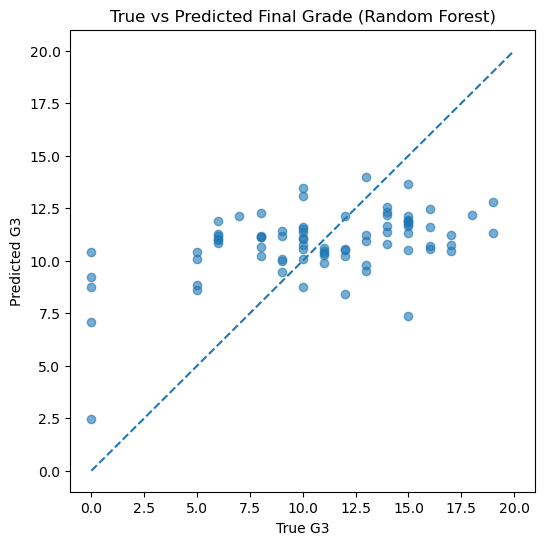

In [15]:
# 11) Simple visualization (optional)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot([0, 20], [0, 20], "--")
plt.xlabel("True G3")
plt.ylabel("Predicted G3")
plt.title("True vs Predicted Final Grade (Random Forest)")
plt.show()

In [16]:
# 12) Example: predict for a new student
example = pd.DataFrame([{
    "studytime": 2,    # (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)
    "failures": 0,
    "absences": 3,
    "famrel": 4,
    "freetime": 3,
    "goout": 2,
    "health": 5,
    "age": 16,
    "sex": "F",
    "address": "U",
    "Medu": 3,
    "Fedu": 2,
    "paid": "no",
    "activities": "yes"
}])
pred = best_rf.predict(example)[0]
print(f"Predicted final grade G3 for example student: {pred:.2f} / 20")

Predicted final grade G3 for example student: 11.44 / 20
